In [0]:
##Carrgando os dados limpos
df = spark.table("workspace.default.vr_education_clean")

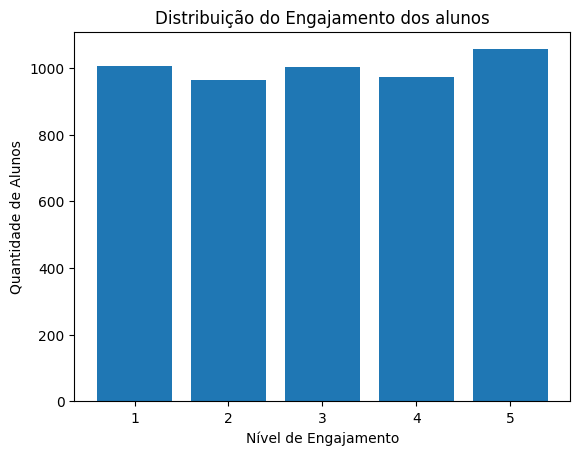

In [0]:
##Distribuição do engajamento

import matplotlib.pyplot as plt

engagement = df.groupBy("engagement_level").count().orderBy("engagement_level").toPandas()

plt.figure()
plt.bar(engagement["engagement_level"], engagement["count"])
plt.xlabel("Nível de Engajamento")
plt.ylabel("Quantidade de Alunos")
plt.title("Distribuição do Engajamento dos alunos")
plt.show()


Insight do nível de engajamento

O engajamento dos alunos apresenta distribuição equilibrada entr os niveis 1 a 5, sem concentração significativa em níveis extremos.
Isso indica que o uso de VR anda gera experiências variadas entre usuários, gugerindo um estágio de adoção em amadurecimento.

Não há dominância de alto engajamento ainda

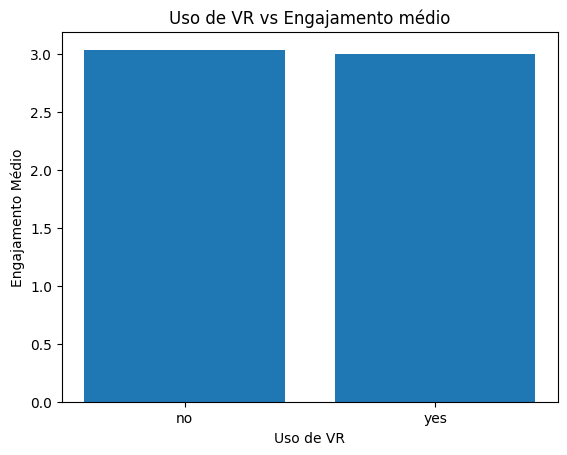

In [0]:
vr_engagement = df.groupBy("usage_of_vr_in_education") \
    .agg({"engagement_level": "avg"}) \
        .toPandas()

plt.figure()
plt.bar(vr_engagement["usage_of_vr_in_education"], vr_engagement["avg(engagement_level)"])
plt.xlabel("Uso de VR")
plt.ylabel("Engajamento Médio")
plt.title("Uso de VR vs Engajamento médio")
plt.show()                

VR vs Engajamento

O uso de VR não apresentou impacto significativo no nível médio de engajamento dos alunos, indicando que, isoladamente, a tecnologia não é um fator detrminante para aumento de engajamento.

In [0]:
from pyspark.sql.functions import when, col, lower

df = df.withColumn(
    "improvement_numeric",
    when(lower(col("improvement_in_learning_outcomes")) == "yes", 1)
    .when(lower(col("improvement_in_learning_outcomes")) == "no", 0)
)

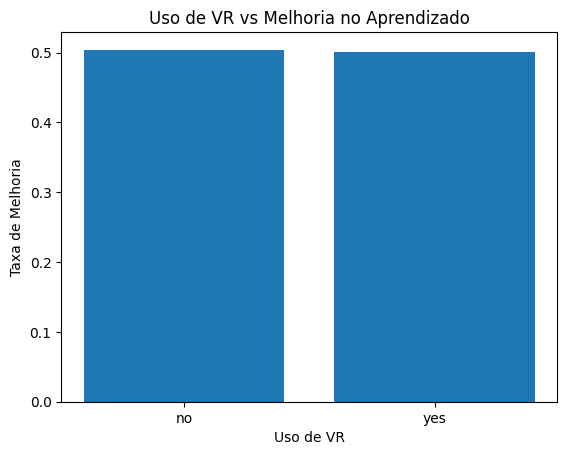

In [0]:
vr_learning = df.groupBy("usage_of_vr_in_education") \
    .agg({"improvement_numeric": "avg"}) \
        .toPandas()

plt.figure()
plt.bar(vr_learning["usage_of_vr_in_education"], vr_learning["avg(improvement_numeric)"])
plt.xlabel("Uso de VR")
plt.ylabel("Taxa de Melhoria")
plt.title("Uso de VR vs Melhoria no Aprendizado")
plt.show()       

Uso de VR vs Aprendizado

O uso de VR não apresenta mudanças significativas no processo de aprendizado

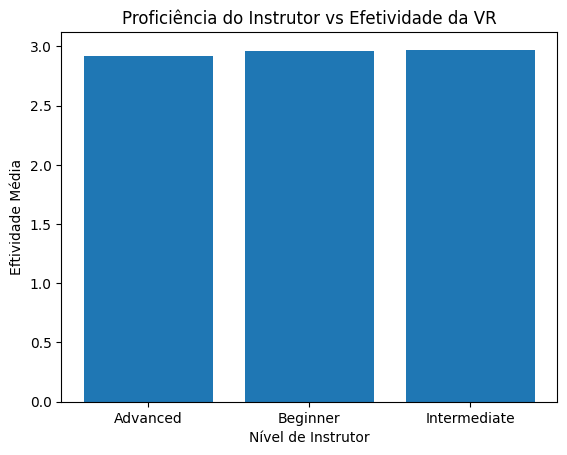

In [0]:
instructor = df.groupBy("instructor_vr_proficiency") \
.agg({"perceived_effectiveness_of_vr": "avg"}) \
    .toPandas()

plt.figure()
plt.bar(instructor["instructor_vr_proficiency"], instructor["avg(perceived_effectiveness_of_vr)"])
plt.xlabel("Nível de Instrutor")
plt.ylabel("Eftividade Média")
plt.title("Proficiência do Instrutor vs Efetividade da VR")
plt.show() 

Instrutores vs Efetividade

Não foi identificada correlação positiva entre a proficiência do instrutor em VR e a percepção de eficácia da tecnologia.
Surpreendentemente, instrutores iniciantes apresentam ligeiramnte maior percepção de eficácia, o que pode indicar que fatores como novidade ou abordagem pedagógica têm maior influência do que a habilidade técnica.

Em resumo:
- Pode ser efeito de novidade
- Pode ser menos expectativa
- Pode indicar que VR ainda não depende de expertise avançada




































































































































































































































































































































































































































































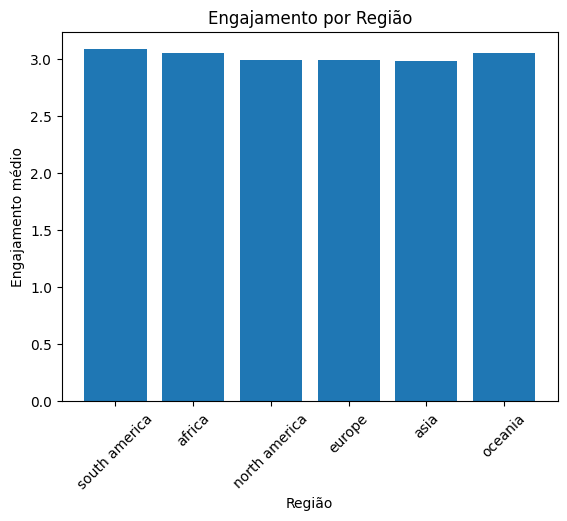

In [0]:
region = df.groupBy("region") \
    .agg({"engagement_level": "avg"}) \
        .toPandas()

plt.figure()
plt.bar(region["region"], region["avg(engagement_level)"])
plt.xlabel("Região")
plt.ylabel("Engajamento médio")
plt.title("Engajamento por Região")
plt.xticks(rotation=45)
plt.show()        

Engajamento por Região

A América do Sul apresentou o maior nível médio de engajamento com VR, enquanto outras regiões mantiveram níveis semelhantes entre si.
No entanto, as diferenças são pequenas, indicando que fatores regionais têm impacto limitado na experiência com VR.
